In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AND Gate Using MCP Neuron

In [2]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND logic using MCP neuron.

    Parameters:
    X1, X2 : Lists of binary inputs
    T : Threshold value

    Returns:
    state_neuron : Output list (0 or 1)
    """

    # Ensure both input lists have same length
    assert len(X1) == len(X2)

    # Store output results
    state_neuron = []

    # Loop through inputs
    for i in range(len(X1)):
        # Step 1: Aggregate inputs (sum)
        summation = X1[i] + X2[i]

        # Step 2: Apply threshold
        if summation >= T:
            state_neuron.append(1)  # Neuron fires
        else:
            state_neuron.append(0)  # Neuron does not fire

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold for AND

result_and = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result_and)

AND Output: [0, 0, 0, 1]


OR Gate Using MCP Neuron

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR logic using MCP neuron.
    """

    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        # Aggregate inputs
        summation = X1[i] + X2[i]

        # Apply threshold
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
T = 1  # Threshold for OR

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)

OR Output: [0, 1, 1, 1]


Limitations of MCP Neuron:
- MCP neuron cannot learn from data (no learning mechanism)
- Uses fixed weights and threshold (manual tuning required)
- Cannot handle non-linearly separable problems (e.g., XOR)
- Very simple model (not suitable for complex problems)
- No adaptability or optimization capability

Can MCP solve XOR?

No, a single MCP neuron cannot solve the XOR function.
- XOR is not linearly separable.
- MCP neuron works as a linear classifier.
- To solve XOR, we need multiple neurons (multi-layer network).

PERCEPTRON (0 vs 1)

In [5]:
# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv")

# Split features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


What does the shape of X represent?

The shape of X represents:
- number of samples (rows)
- number of features    (columns)


*   List item
*   List item



What does the shape of Y represent?

The shape of y represents:
- number of labels corresponding to each samples.

Each value is either 0 or 1.




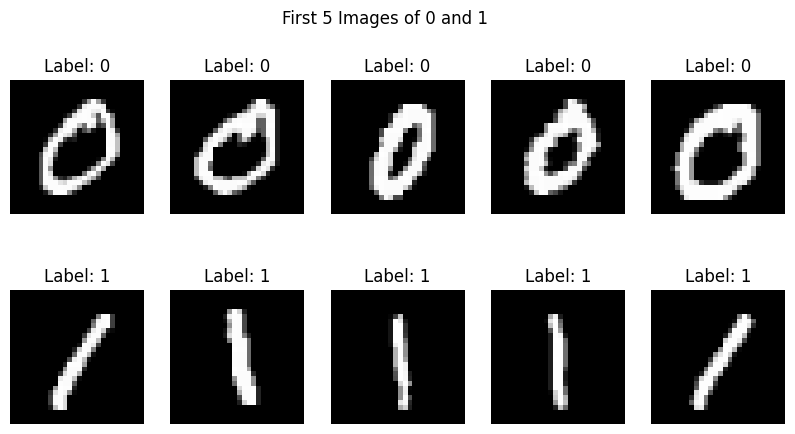

In [7]:
#Visualize the dataset
# Separate images based on label
images_0 = X[y == 0]  # All digit 0 images
images_1 = X[y == 1]  # All digit 1 images

# Create subplot (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if enough images exist
if len(images_0) < 5 or len(images_1) < 5:
    print("Not enough images to display")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

# Show the plot
plt.suptitle("First 5 Images of 0 and 1")
plt.show()

In [8]:
# Initialize weights (one weight per pixel)
weights = np.zeros(X.shape[1])  # 784 weights

# Initialize bias
bias = 0

# Learning parameters
learning_rate = 0.1
epochs = 100

What does the weights array represent in this context?


- represents importance of each feature (pixel).
- each weight corresponds to one pixel.
- determines contribution to prediction.

 Why are we initializing the weights to zero? What effect could this
have on the training process?

- simple starting point.
- all features treated equally initially.
- weights updated during training.


In [13]:
#Implementing Decision Function:

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """

    # Compute weighted sum of inputs
    predictions = np.dot(X, weights) + bias

    # Apply step activation function:
    # If prediction >= 0 → class 1, else class 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

In [15]:
#Training the Perceptron:

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates
    - epochs: Number of iterations

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction
    """

    # Loop through epochs
    for epoch in range(epochs):

        # Loop through each training sample
        for i in range(len(X)):

            # Compute weighted sum
            output = np.dot(X[i], weights) + bias

            # Apply step function
            y_pred = 1 if output >= 0 else 0

            # Update weights and bias if prediction is wrong
            if y_pred != y[i]:

                # Update weights using perceptron rule
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]

                # Update bias
                bias = bias + learning_rate * (y[i] - y_pred)

    # Final predictions after training
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)

    # Calculate accuracy
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

What is the purpose of output = np.dot(X[i], weights) + bias?
- computes weighted sum of inputs.
- combines input features with weights.
- bias shifts decision boundary.

What happens when the prediction is wrong? How are the weights and bias updated?

When the prediction is wrong, the model updates its weight and bias.

Weights are updated:
w = w + η(y - ŷ)x

Bias is updated:
b = b + η(y - ŷ)

Why is the final accuracy important, and what do you expect it to be?

- measures model performance.
- shows how many predictions are correct.
Expected high (~100%) for 0 vs 1

In [17]:
#Training the Perceptron Algorithmn
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


In [18]:
#Visualizing Misclassified Image
# Get predictions for all data points
predictions = np.dot(X, weights) + bias

# Apply step function to convert into class labels
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Find indices where prediction is incorrect
misclassified_idx = np.where(y_pred != y)[0]

# If there are misclassified images, display them
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    # Show first 10 misclassified images
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


What does misclassified idx store, and how is it used in this code?

- stores indices of incorrectly predicted samples.
- identifies where predicted labels ≠ actual labels.

Used to:

- select misclassified images.
- display them using imshow().

 How do you interpret the result if the output is ”All images were
correctly classified!”?

- model achieved 100% accuracy.
- no misclassification occurred.
- dataset is linearly separable.

In [23]:
# Load dataset for digits 3 and 5
df = pd.read_csv("mnist_3_and_5.csv")

# Extract features and labels
X = df.drop(columns=["label"]).values
y = df["label"].values

# Convert labels: 3 → 0, 5 → 1 (for binary classification)
y = np.where(y == 3, 0, 1)

In [24]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.1
epochs = 100

In [25]:
# Train perceptron on new dataset
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.986866107260124


Final Accuracy: 0.9869


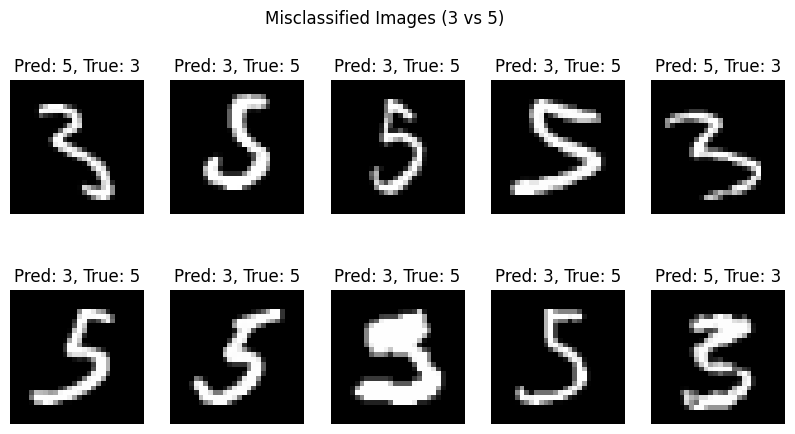

In [27]:
# Get predictions
predictions = np.dot(X, weights) + bias

# Apply step function
y_pred = np.where(predictions >= 0, 1, 0)

# Accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

# Plot misclassified images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):

        # Convert labels back to original (3 and 5)
        pred_label = 3 if y_pred[idx] == 0 else 5
        true_label = 3 if y[idx] == 0 else 5

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion for 3 vs 5 classification:

- the perceptron achieved high accuracy (~98%).
- some misclassified images are still observed.
- digits 3 and 5 have similar shapes, causing confusion.
- the model is not able to perfectly separate the data.
- perceptron works well for simple datasets (like 0 vs 1).
- performance decreases for more complex patterns.
- this demonstrates the limitation of perceptron.
- it can only learn linear decision boundaries.
- it cannot fully handle complex or overlapping data.